In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.8 MB/s eta 0:00:00


In [2]:
import torch

print("GPU Available:" , torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU Name:" , torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [4]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_b34065b1ce412acf3fb0827d019c6ebf'

In [5]:
!pip install -q kaggle

In [6]:
!kaggle datasets download -d ugorjiir/spacenet-2-paris-buildings

Dataset URL: https://www.kaggle.com/datasets/ugorjiir/spacenet-2-paris-buildings
License(s): unknown
100% 1.62G/1.62G [01:35<00:00, 18.2MB/s]



In [7]:
!unzip -q spacenet-2-paris-buildings.zip

In [8]:
!ls

AOI_3_Paris_Test_public  sample_data
AOI_3_Paris_Train	 spacenet-2-paris-buildings.zip


In [9]:
!find . | head -100

.
./.config
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/logs
./.config/logs/2026.06.04
./.config/logs/2026.06.04/13.39.24.274402.log
./.config/logs/2026.06.04/13.39.36.079406.log
./.config/logs/2026.06.04/13.39.12.467650.log
./.config/logs/2026.06.04/13.39.22.644527.log
./.config/logs/2026.06.04/13.39.37.138439.log
./.config/logs/2026.06.04/13.38.54.010366.log
./.config/configurations
./.config/configurations/config_default
./.config/.last_update_check.json
./.config/default_configs.db
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/active_config
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./spacenet-2-paris-buildings.zip
./AOI_3_Paris_Train
./AOI_3_Paris_Train/AOI_3_Paris_Train
./AOI_3_Paris_Train/AOI_3_Paris_Train/geojson
./AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings
./AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img817.geojson
./AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buil

In [10]:
!find AOI_3_Paris_Train | head -50

AOI_3_Paris_Train
AOI_3_Paris_Train/AOI_3_Paris_Train
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img817.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img37.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img240.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img681.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img203.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img1501.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img217.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img673.geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img1275.geojson
AOI_3_Paris_Train/AOI_3_Pari

In [11]:
!ls AOI_3_Paris_Train

AOI_3_Paris_Train


In [12]:
!find AOI_3_Paris_Train -type f | grep -E "\.(tif|jpg|png)$" | head -50

AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img680.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img4.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img551.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img214.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img86.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img328.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img820.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img110.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1644.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img168.tif
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img95.tif
AOI_3_Paris_Train/AOI_3_

In [13]:
!find AOI_3_Paris_Train -maxdepth 3 -type d

AOI_3_Paris_Train
AOI_3_Paris_Train/AOI_3_Paris_Train
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson
AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings
AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen
AOI_3_Paris_Train/AOI_3_Paris_Train/summaryData


In [14]:
!pip install geopandas rasterio shapely -q

In [15]:
import geopandas as gpd

sample_file = "AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img4.geojson"

gdf = gpd.read_file(sample_file)

print(gdf.head())
print("/nColumns:" , gdf.columns)

Empty GeoDataFrame
Columns: [geometry]
Index: []
/nColumns: Index(['geometry'], dtype='object')


In [16]:
import rasterio

img_path = "AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img4.tif"

with rasterio.open(img_path) as src:
    print("Width:", src.width)
    print("Height:", src.height)

Width: 650
Height: 650


In [17]:
import geopandas as gpd
from glob import glob

files = glob("AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/*.geojson")

for f in files[:20]:
    gdf = gpd.read_file(f)
    print(f.split("/")[-1], "->", len(gdf))

buildings_AOI_3_Paris_img817.geojson -> 38
buildings_AOI_3_Paris_img37.geojson -> 5
buildings_AOI_3_Paris_img240.geojson -> 44
buildings_AOI_3_Paris_img681.geojson -> 44
buildings_AOI_3_Paris_img203.geojson -> 17
buildings_AOI_3_Paris_img1501.geojson -> 36
buildings_AOI_3_Paris_img217.geojson -> 23
buildings_AOI_3_Paris_img673.geojson -> 0
buildings_AOI_3_Paris_img1275.geojson -> 16
buildings_AOI_3_Paris_img1535.geojson -> 0
buildings_AOI_3_Paris_img935.geojson -> 0
buildings_AOI_3_Paris_img1334.geojson -> 0
buildings_AOI_3_Paris_img1740.geojson -> 37
buildings_AOI_3_Paris_img693.geojson -> 16
buildings_AOI_3_Paris_img1172.geojson -> 0
buildings_AOI_3_Paris_img1711.geojson -> 0
buildings_AOI_3_Paris_img1109.geojson -> 1
buildings_AOI_3_Paris_img1103.geojson -> 24
buildings_AOI_3_Paris_img649.geojson -> 32
buildings_AOI_3_Paris_img1854.geojson -> 19


In [19]:
import geopandas as gpd

sample_file = "AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img817.geojson"

gdf = gpd.read_file(sample_file)

print(gdf.head())
print("\nColumns:", gdf.columns)
print("\nNumber of buildings:", len(gdf))

   OBJECTID_1 Name_1  AREA_1  Shape_Leng  Shape_Le_1  Shape_Area  \
0           0   None     0.0         0.0    0.000239         0.0   
1           0   None     0.0         0.0    0.000386         0.0   
2           0   None     0.0         0.0    0.000204         0.0   
3           0   None     0.0         0.0    0.000542         0.0   
4           0   None     0.0         0.0    0.000406         0.0   

   partialBuilding  partialDec  \
0              1.0    0.093251   
1              1.0    0.122587   
2              0.0    1.000000   
3              1.0    0.766976   
4              0.0    1.000000   

                                            geometry  
0  POLYGON Z ((2.25767 48.98453 0, 2.25768 48.984...  
1  POLYGON Z ((2.25804 48.98453 0, 2.25806 48.984...  
2  POLYGON Z ((2.25777 48.98457 0, 2.25774 48.984...  
3  POLYGON Z ((2.25804 48.98458 0, 2.258 48.98453...  
4  POLYGON Z ((2.25704 48.98463 0, 2.25699 48.984...  

Columns: Index(['OBJECTID_1', 'Name_1', 'AREA_1', 'Shap

In [20]:
import rasterio

img_path = "AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img817.tif"

with rasterio.open(img_path) as src:
    print("CRS:", src.crs)
    print("Transform:")
    print(src.transform)

CRS: EPSG:4326
Transform:
| 0.00, 0.00, 2.26|
| 0.00,-0.00, 48.99|
| 0.00, 0.00, 1.00|


In [21]:
with rasterio.open(img_path) as src:
    print("Bounds:", src.bounds)

Bounds: BoundingBox(left=2.25661139994, bottom=48.9845259, right=2.25836639994, top=48.9862809)


In [22]:
import geopandas as gpd
import rasterio

geojson_file = "AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings/buildings_AOI_3_Paris_img817.geojson"

image_file = "AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img817.tif"

gdf = gpd.read_file(geojson_file)

with rasterio.open(image_file) as src:
    width = src.width
    height = src.height

    print("Image size:", width, height)

    poly = gdf.geometry.iloc[0]

    minx, miny, maxx, maxy = poly.bounds

    row1, col1 = src.index(minx, maxy)
    row2, col2 = src.index(maxx, miny)

    print("Pixel bounding box:")
    print(col1, row1, col2, row2)


Image size: 650 650
Pixel bounding box:
393 645 411 649


In [23]:
from glob import glob

images = glob("AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/*.tif")
print("Number of images:", len(images))

Number of images: 1148


## Converting GeoJSON Annotations to YOLO Format

The SpaceNet dataset provides building annotations as GeoJSON polygons. Since YOLOv8 requires bounding boxes in YOLO text format, the annotations are first converted from geographic polygons to pixel-based bounding boxes and then saved as YOLO label files.

In [24]:
import os
import shutil
from glob import glob
from sklearn.model_selection import train_test_split

# Source image folder
image_dir = "AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen"

# Create YOLO folder structure
for split in ["train", "val", "test"]:
    os.makedirs(f"dataset/images/{split}", exist_ok=True)
    os.makedirs(f"dataset/labels/{split}", exist_ok=True)

# Collect all images
images = sorted(glob(os.path.join(image_dir, "*.tif")))

print("Total images:", len(images))

# 80 / 10 / 10 split
train_imgs, temp_imgs = train_test_split(
    images,
    test_size=0.20,
    random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Copy images
for img in train_imgs:
    shutil.copy(img, "dataset/images/train")

for img in val_imgs:
    shutil.copy(img, "dataset/images/val")

for img in test_imgs:
    shutil.copy(img, "dataset/images/test")

print("Image split completed.")

Total images: 1148
Train: 918
Validation: 115
Test: 115
Image split completed.


In [25]:
!ls dataset/images/train | wc -l
!ls dataset/images/val | wc -l
!ls dataset/images/test | wc -l

918
115
115


### Generating YOLO Bounding Box Labels

In [26]:
import os
import geopandas as gpd
import rasterio
from glob import glob
from tqdm import tqdm

# GeoJSON folder
geojson_dir = "AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings"

def create_yolo_label(image_path, label_path):

    image_name = os.path.basename(image_path)

    img_id = image_name.replace("RGB-PanSharpen_", "").replace(".tif", "")

    geojson_file = os.path.join(
        geojson_dir,
        f"buildings_{img_id}.geojson"
    )

    with rasterio.open(image_path) as src:
        width = src.width
        height = src.height

        if not os.path.exists(geojson_file):
            open(label_path, "w").close()
            return

        gdf = gpd.read_file(geojson_file)

        with open(label_path, "w") as f:

            for poly in gdf.geometry:

                if poly is None:
                    continue

                minx, miny, maxx, maxy = poly.bounds

                row1, col1 = src.index(minx, maxy)
                row2, col2 = src.index(maxx, miny)

                x1 = min(col1, col2)
                x2 = max(col1, col2)

                y1 = min(row1, row2)
                y2 = max(row1, row2)

                x_center = ((x1 + x2) / 2) / width
                y_center = ((y1 + y2) / 2) / height

                box_width = (x2 - x1) / width
                box_height = (y2 - y1) / height

                f.write(
                    f"0 {x_center} {y_center} {box_width} {box_height}\n"
                )

# Generate labels for all splits
for split in ["train", "val", "test"]:

    image_folder = f"dataset/images/{split}"
    label_folder = f"dataset/labels/{split}"

    image_files = glob(os.path.join(image_folder, "*.tif"))

    for image_file in tqdm(image_files, desc=split):

        label_file = os.path.join(
            label_folder,
            os.path.basename(image_file).replace(".tif", ".txt")
        )

        create_yolo_label(image_file, label_file)

print("All YOLO labels generated successfully.")

test: 100%|██████████| 115/115 [00:00<00:00, 163.91it/s]

All YOLO labels generated successfully.


In [27]:
!ls dataset/labels/train | wc -l
!ls dataset/labels/val | wc -l
!ls dataset/labels/test | wc -l

918
115
115


In [31]:
sample_label = "dataset/labels/train/" + os.listdir("dataset/labels/train")[0]

with open(sample_label) as f:
  print(f.read()[:500])

In [32]:
import os

for file in os.listdir("dataset/labels/train"):
    path = os.path.join("dataset/labels/train", file)

    if os.path.getsize(path) > 0:
        print("Found:", file)

        with open(path) as f:
            print(f.read()[:500])

        break

Found: RGB-PanSharpen_AOI_3_Paris_img822.txt
0 0.78 0.9961538461538462 0.021538461538461538 0.004615384615384616
0 0.09846153846153846 0.9953846153846154 0.024615384615384615 0.006153846153846154
0 0.35384615384615387 0.9923076923076923 0.06461538461538462 0.012307692307692308
0 0.6346153846153846 0.9892307692307692 0.07538461538461538 0.018461538461538463
0 0.7084615384615385 0.9761538461538461 0.10615384615384615 0.04461538461538461
0 0.21615384615384614 0.9623076923076923 0.09692307692307692 0.06307692307692307
0 0.5476923076923077 0.93


#step 2.2 : visualizing training images and bounding boxes

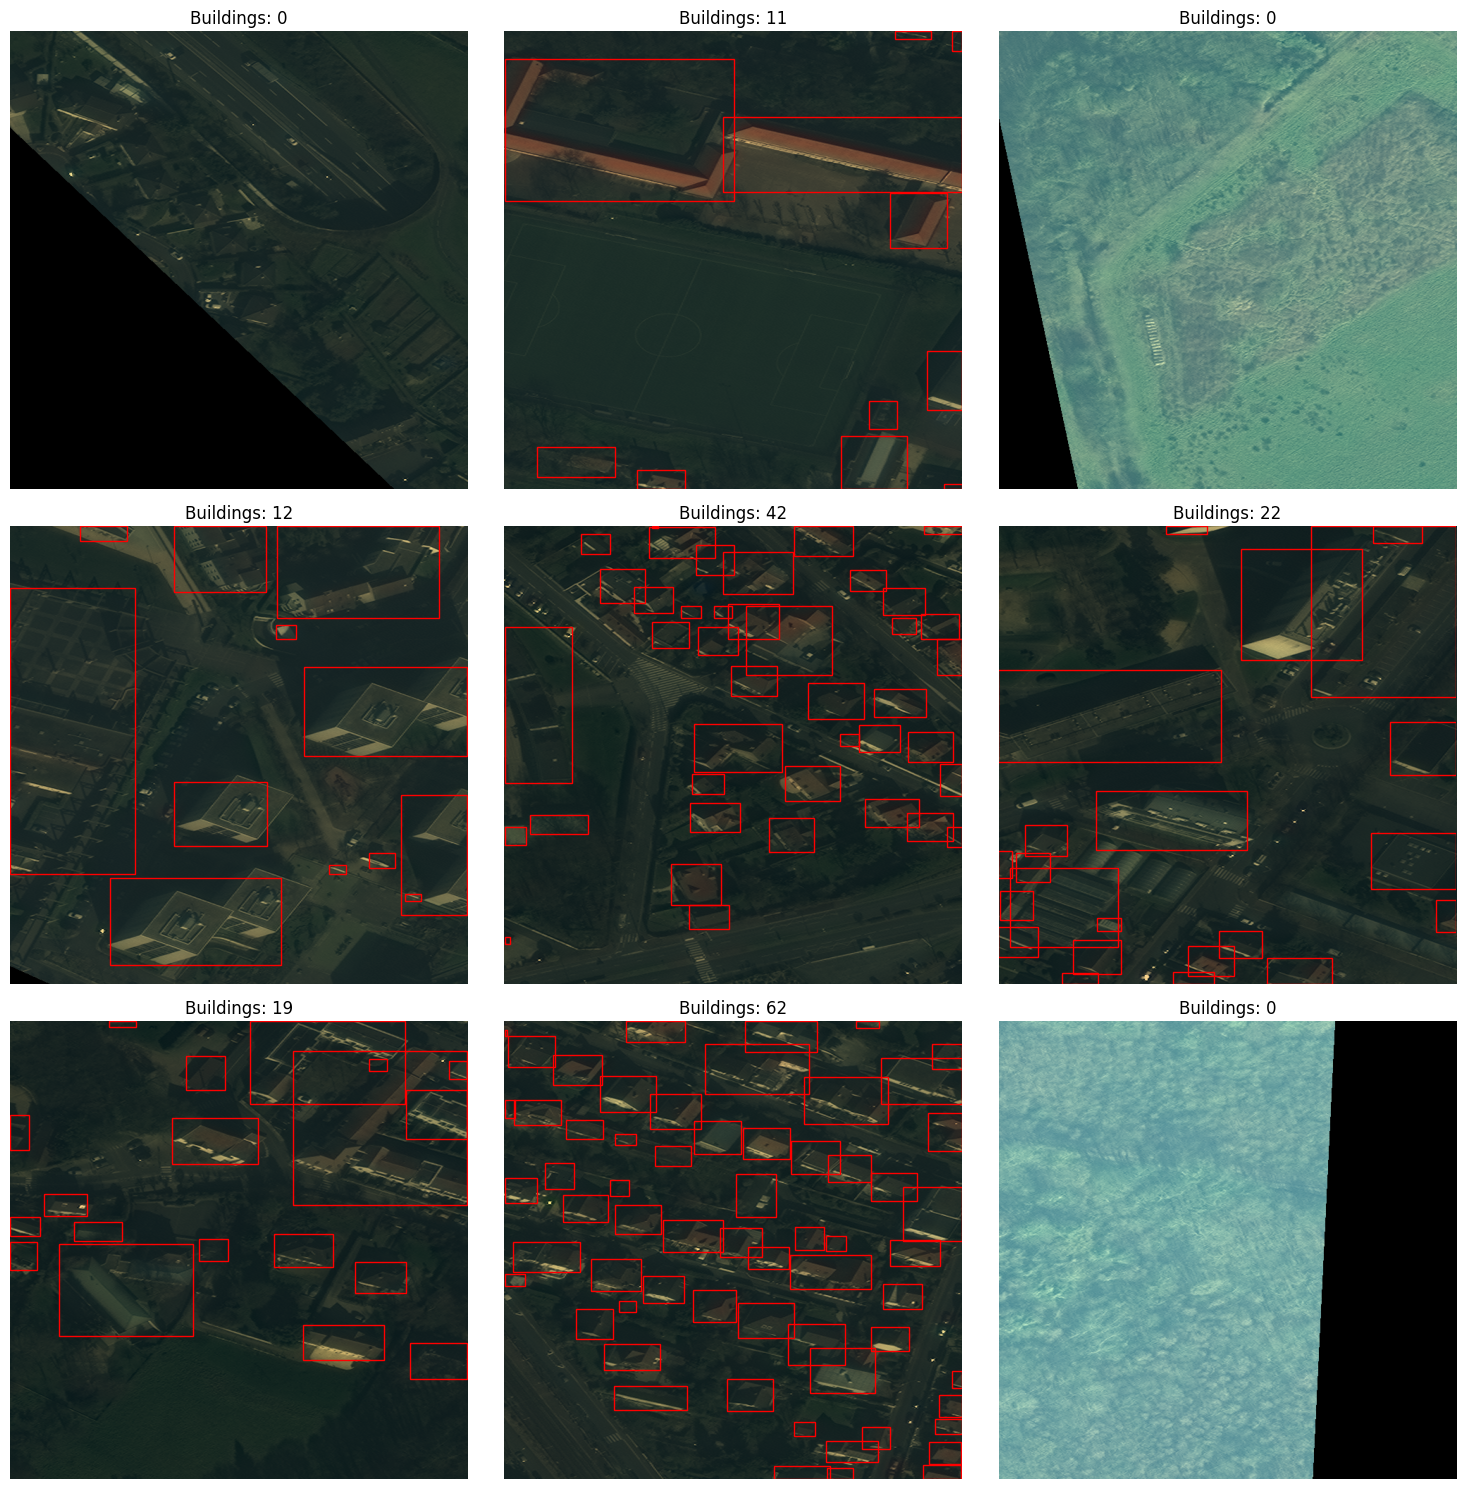

In [36]:
import random
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

train_img_dir = "dataset/images/train"
train_label_dir = "dataset/labels/train"

image_files = random.sample(os.listdir(train_img_dir), 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, img_name in zip(axes.ravel(), image_files):

    img_path = os.path.join(train_img_dir, img_name)

    # Read TIFF
    with rasterio.open(img_path) as src:
        image = src.read([1, 2, 3])

    image = image.transpose(1, 2, 0).astype(np.float32)

    # Normalize
    image = (image - image.min()) / (image.max() - image.min())

    h, w = image.shape[:2]

    label_path = os.path.join(
        train_label_dir,
        img_name.replace(".tif", ".txt")
    )

    building_count = 0

    ax.imshow(image)

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            lines = f.readlines()
            building_count = len(lines)

            for line in lines:

                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h

                rect = patches.Rectangle(
                    (x1, y1),
                    bw * w,
                    bh * h,
                    linewidth=1,
                    edgecolor='red',
                    facecolor='none'
                )

                ax.add_patch(rect)

    ax.set_title(f"Buildings: {building_count}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Dataset Statistics

In [37]:
import os

total_buildings = 0
total_images = 0

for split in ["train", "val", "test"]:

    label_dir = f"dataset/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir, file), "r") as f:
            total_buildings += len(f.readlines())

        total_images += 1

avg_buildings = total_buildings / total_images

print("Total Images:", total_images)
print("Total Buildings:", total_buildings)
print("Average Buildings per Image:", round(avg_buildings, 2))

Total Images: 1148
Total Buildings: 16478
Average Buildings per Image: 14.35


## Observations

### What is the average number of buildings per image?

The dataset contains 16,478 building annotations across 1,148 images, resulting in an average of approximately **14.35 buildings per image**. However, the distribution is not uniform. Some images contain dense clusters of buildings, while others contain very few or no buildings.

### Do images look consistent in size and quality?

Yes. The images appear to be consistent in both size and quality. Each image has a resolution of **650 × 650 pixels** and originates from the same satellite imagery source. The visual characteristics, color distribution, and spatial resolution remain largely consistent throughout the dataset.

### What challenges might the model face?

The model may face several challenges during training:

- Dense building clusters where multiple buildings are located very close to one another.
- Small rooftops that occupy only a limited number of pixels and may be difficult to detect.
- Partial buildings appearing near image boundaries.
- Variations in building shapes and sizes, ranging from small residential structures to larger buildings.
- Background confusion caused by roads, vegetation, and other urban features that may resemble rooftops.
- Class imbalance, as some images contain many buildings while others contain none.

## Creating dataset.yaml for YOLOv8

In [38]:
yaml_content = """
path: dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created successfully!")

dataset.yaml created successfully!


In [39]:
with open("dataset.yaml", "r") as f:
    print(f.read())


path: dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building



## Verifying Dataset Structure

In [42]:
import os

for split in ["train", "val", "test"]:

    image_count = len(os.listdir(f"dataset/images/{split}"))
    label_count = len(os.listdir(f"dataset/labels/{split}"))

    print(f"{split.upper()}")
    print("Images:", image_count)
    print("Labels:", label_count)
    print("-"*30)

TRAIN
Images: 918
Labels: 918
------------------------------
VAL
Images: 115
Labels: 115
------------------------------
TEST
Images: 115
Labels: 115
------------------------------


## Training YOLOv8 on SpaceNet Buildings Dataset

In [43]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

RuntimeError: No valid images found in /content/dataset/labels/train.cache.
  [34m[1mtrain: [0m/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img10.tif: ignoring corrupt image/label: cannot identify image file '/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img10.tif'
  [34m[1mtrain: [0m/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img100.tif: ignoring corrupt image/label: cannot identify image file '/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img100.tif'
  [34m[1mtrain: [0m/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img1000.tif: ignoring corrupt image/label: cannot identify image file '/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img1000.tif'
  [34m[1mtrain: [0m/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img1003.tif: ignoring corrupt image/label: cannot identify image file '/content/dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img1003.tif'
  [34m[1mtrain: [0m/content/dataset/images/trai

In [44]:
from PIL import Image

img_path = "dataset/images/train/" + os.listdir("dataset/images/train")[0]

try:
    img = Image.open(img_path)
    print("PIL can read this image.")
except Exception as e:
    print("Error:", e)

Error: cannot identify image file 'dataset/images/train/RGB-PanSharpen_AOI_3_Paris_img680.tif'


## Converting GeoTIFF Images to PNG Format

In [45]:
import os
import rasterio
import numpy as np
from PIL import Image
from tqdm import tqdm

for split in ["train", "val", "test"]:

    image_dir = f"dataset/images/{split}"

    tif_files = [
        f for f in os.listdir(image_dir)
        if f.endswith(".tif")
    ]

    for tif_file in tqdm(tif_files, desc=f"Converting {split}"):

        tif_path = os.path.join(image_dir, tif_file)

        with rasterio.open(tif_path) as src:
            img = src.read([1, 2, 3])

        img = img.transpose(1, 2, 0).astype(np.float32)

        # Normalize to 0-255
        img = (img - img.min()) / (img.max() - img.min())
        img = (img * 255).astype(np.uint8)

        png_name = tif_file.replace(".tif", ".png")
        png_path = os.path.join(image_dir, png_name)

        Image.fromarray(img).save(png_path)

print("PNG conversion completed!")

Converting test: 100%|██████████| 115/115 [00:23<00:00,  4.81it/s]

PNG conversion completed!


In [46]:
from PIL import Image
import os

sample_png = [
    f for f in os.listdir("dataset/images/train")
    if f.endswith(".png")
][0]

img = Image.open(
    os.path.join("dataset/images/train", sample_png)
)

print("PNG size:", img.size)
print("Mode:", img.mode)

PNG size: (650, 650)
Mode: RGB


In [47]:
import os

for split in ["train", "val", "test"]:

    image_dir = f"dataset/images/{split}"

    for file in os.listdir(image_dir):

        if file.endswith(".tif"):
            os.remove(
                os.path.join(image_dir, file)
            )

print("All TIFF files removed.")

All TIFF files removed.


In [48]:
for split in ["train", "val", "test"]:

    png_count = len([
        f for f in os.listdir(f"dataset/images/{split}")
        if f.endswith(".png")
    ])

    print(split, png_count)

train 918
val 115
test 115


In [50]:
for split in ["train", "val", "test"]:

    image_count = len(os.listdir(f"dataset/images/{split}"))
    label_count = len(os.listdir(f"dataset/labels/{split}"))

    print(f"{split.upper()}")
    print("Images:", image_count)
    print("Labels:", label_count)
    print("-"*30)

TRAIN
Images: 918
Labels: 918
------------------------------
VAL
Images: 115
Labels: 115
------------------------------
TEST
Images: 115
Labels: 115
------------------------------


## Training YOLOv8 Model

In [51]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

## Why Use YOLOv8 Pretrained Weights?

We use pretrained YOLOv8 weights instead of starting from random weights because the model has already learned useful visual features such as edges, shapes, and textures from a large dataset. This allows the model to converge faster, requires less training data, and usually produces better performance than training entirely from scratch.

In [52]:
import pandas as pd

results = pd.read_csv("/content/runs/detect/train-2/results.csv")

results.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,427.187,1.40741,0.93638,1.18663,0.79480,0.72480,0.77935,0.45147,1.41089,0.88889,1.19855,0.000515,0.000515,0.000515
16,17,452.375,1.39470,0.92604,1.17968,0.81466,0.71553,0.78293,0.45441,1.39598,0.87099,1.18738,0.000416,0.000416,0.000416
17,18,478.134,1.37057,0.89365,1.16234,0.82566,0.70568,0.78603,0.46140,1.37243,0.86842,1.17715,0.000317,0.000317,0.000317
18,19,503.027,1.35862,0.87959,1.15917,0.83883,0.70742,0.78928,0.46253,1.37988,0.86319,1.17706,0.000218,0.000218,0.000218
19,20,527.393,1.35241,0.87147,1.16182,0.82924,0.70621,0.79471,0.46816,1.36850,0.83818,1.17304,0.000119,0.000119,0.000119


## Final Training Metrics

The final training metrics obtained after 20 epochs are:

- Final Training Box Loss: **1.352**
- Final Validation Box Loss: **1.369**
- Final mAP@50: **0.795**
- Final mAP@50-95: **0.468**

The model achieved a mAP@50 of approximately 79.5%, indicating good performance in detecting buildings from satellite imagery.

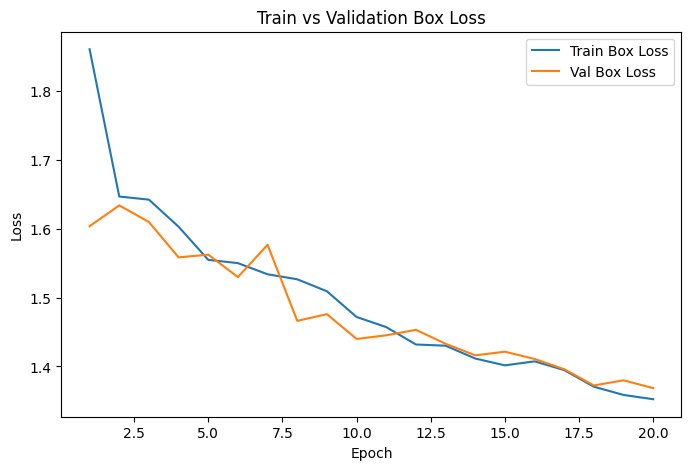

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/runs/detect/train-2/results.csv")
results.columns = results.columns.str.strip()

plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/box_loss"], label="Train Box Loss")
plt.plot(results["epoch"], results["val/box_loss"], label="Val Box Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Box Loss")
plt.legend()
plt.show()

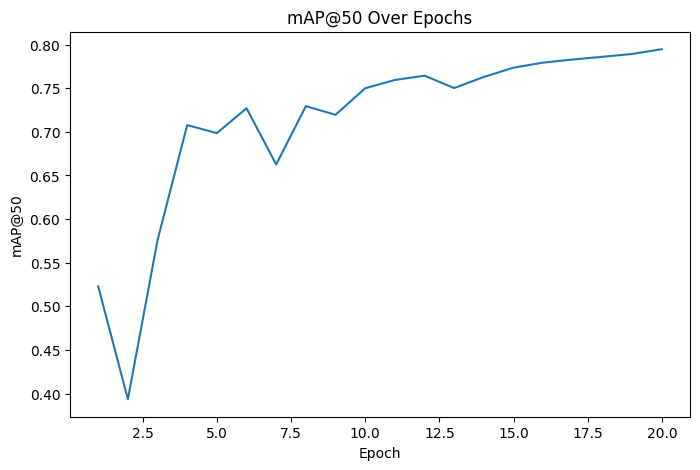

In [54]:
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["metrics/mAP50(B)"])

plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("mAP@50 Over Epochs")
plt.show()

## Training Curve Analysis

The validation box loss generally followed the trend of the training box loss throughout training, indicating that the model was learning consistently without severe overfitting.

The mAP@50 improved steadily during the initial epochs and gradually plateaued toward the end of training. This suggests that the model was approaching convergence, and additional epochs may provide only marginal improvements.

## Test Set Evaluation

| Metric | Your Value | What it means in plain English |
|----------|----------|----------|
| mAP@50 | 0.795 | Measures overall detection accuracy when predicted and true boxes overlap by at least 50%. |
| Precision | 0.830 | About 83% of predicted buildings are actually buildings. |
| Recall | 0.707 | The model successfully detects about 71% of all actual buildings. |
| F1 Score | 0.764 | Balanced measure combining precision and recall. |

In [55]:
import os

for file in sorted(os.listdir("/content/runs/detect/train-2")):
    print(file)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch580.jpg
train_batch581.jpg
train_batch582.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


## Precision-Recall Curve

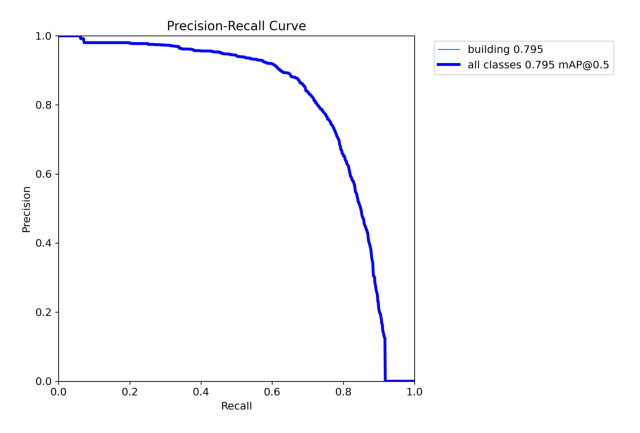

In [56]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/train-2/BoxPR_curve.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Confusion Matrix

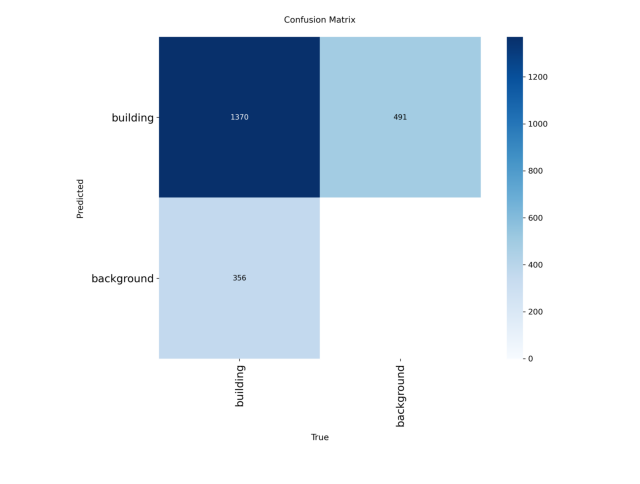

In [58]:
img = Image.open("/content/runs/detect/train-2/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Building Count Comparison on Test Images

In [59]:
import random
import os
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

test_img_dir = "dataset/images/test"
test_label_dir = "dataset/labels/test"

sample_images = random.sample(
    os.listdir(test_img_dir),
    10
)

true_counts = []
pred_counts = []
image_names = []

for img_name in sample_images:

    img_path = os.path.join(test_img_dir, img_name)

    label_path = os.path.join(
        test_label_dir,
        img_name.replace(".png", ".txt")
    )

    with open(label_path, "r") as f:
        true_count = len(f.readlines())

    results = model.predict(
        img_path,
        conf=0.25,
        verbose=False
    )

    pred_count = len(results[0].boxes)

    image_names.append(img_name[-8:-4])
    true_counts.append(true_count)
    pred_counts.append(pred_count)

print("Done")

Done


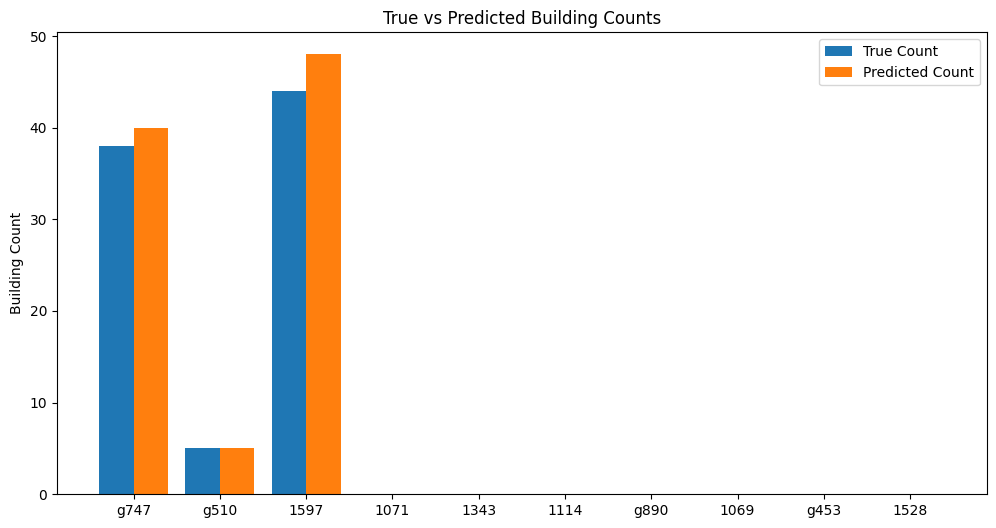

In [60]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(image_names))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    true_counts,
    width,
    label="True Count"
)

plt.bar(
    x + width/2,
    pred_counts,
    width,
    label="Predicted Count"
)

plt.xticks(x, image_names)
plt.ylabel("Building Count")
plt.title("True vs Predicted Building Counts")

plt.legend()
plt.show()

In [61]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    true_counts,
    pred_counts
)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 0.6


## Building Count Evaluation

The building counting pipeline was evaluated on 10 randomly selected test images.

The Mean Absolute Error (MAE) obtained was **0.6**, indicating that the predicted building count differed from the true count by less than one building on average.

This demonstrates that the trained YOLOv8 model is able to accurately detect and count buildings in satellite imagery.

## Final Building Detection Pipeline

In [64]:
import time
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

def detect_buildings(image_path):

    start_time = time.time()

    results = model.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    detections = results[0]

    building_count = len(detections.boxes)

    confidences = []

    for box in detections.boxes:
        confidences.append(float(box.conf))

    avg_conf = (
        np.mean(confidences)
        if len(confidences) > 0
        else 0
    )

    processing_time = (
        time.time() - start_time
    ) * 1000

    with rasterio.open(image_path) as src:
        original = src.read([1,2,3])

    original = original.transpose(1,2,0)

    annotated = results[0].plot()

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(12,6)
    )

    ax[0].imshow(original)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(annotated)
    ax[1].set_title("Detected Buildings")
    ax[1].axis("off")

    plt.show()

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {building_count}")
    print(f"Average confidence: {avg_conf:.2f}")
    print(f"Processing time: {processing_time:.1f} ms")

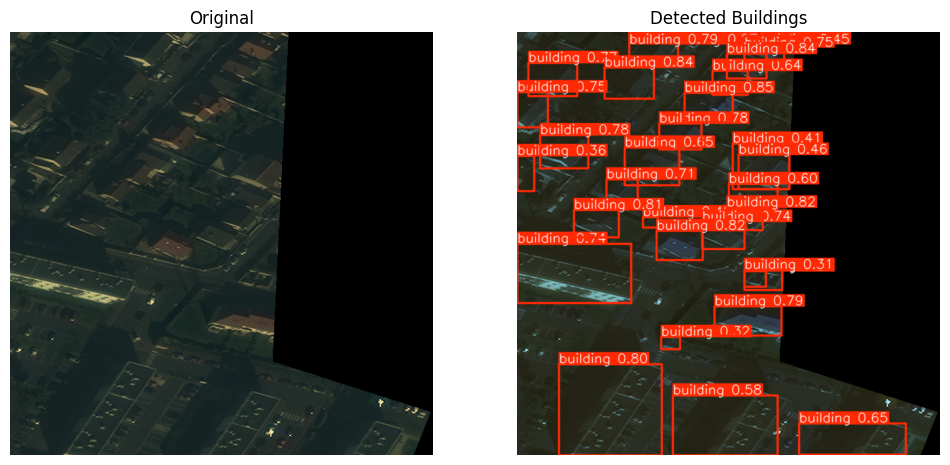

Image: RGB-PanSharpen_AOI_3_Paris_img1820.png
Buildings detected: 31
Average confidence: 0.64
Processing time: 30.2 ms


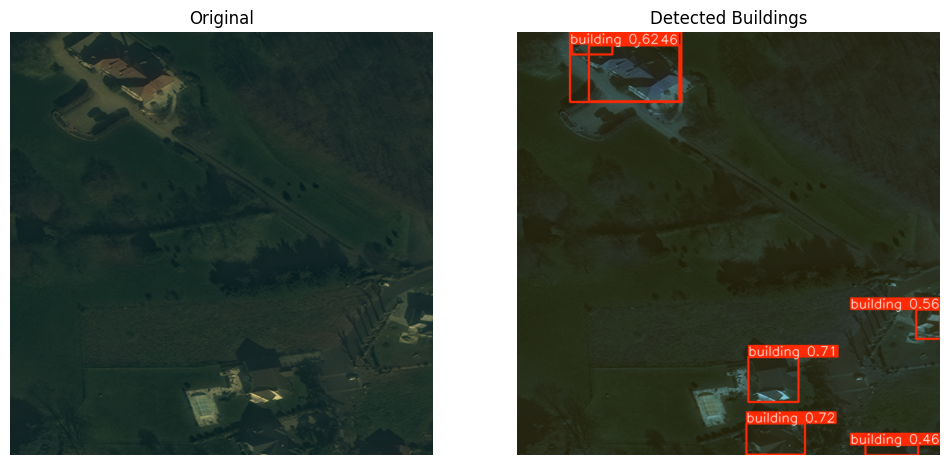

Image: RGB-PanSharpen_AOI_3_Paris_img926.png
Buildings detected: 7
Average confidence: 0.55
Processing time: 35.0 ms


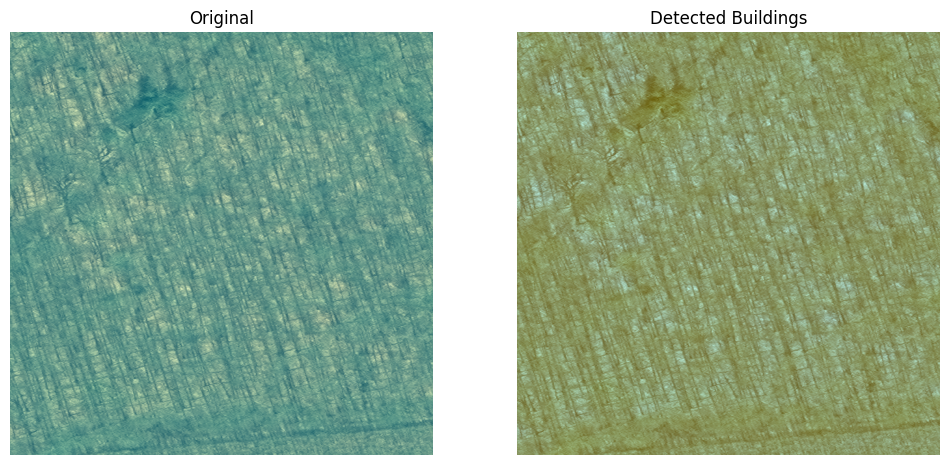

Image: RGB-PanSharpen_AOI_3_Paris_img1471.png
Buildings detected: 0
Average confidence: 0.00
Processing time: 34.4 ms


In [66]:
import random
import os

test_imgs = random.sample(
    os.listdir("dataset/images/test"),
    3
)

for img in test_imgs:

    detect_buildings(
        os.path.join(
            "dataset/images/test",
            img
        )
    )